# The 9 ids flagged `F` in TRANS_1-4 (deep-review, transitional zone)

`scripts/analysis/review_package_deep.py`'s `build_deep` stage stratified the ~1,680-id transitional zone into 5 equal-count logit bands (TRANS_1 = lowest logit/nearest floor .. TRANS_5 = highest logit/nearest ceiling) and sampled 80 ids/band for manual review (see `scripts/analysis/review_package_deep_report.md`). TRANS_5 sits right up against the ceiling mode, so a high `F` (fraud-looking) rate there is the expected boundary effect -- TRANS_1-4 is where a genuinely *hidden*, low-ranked fraud would show up, and that's exactly what the ingest (`review_package_deep_ingest_report.md`) found: 9 ids across TRANS_1/3/4 (TRANS_2 came back clean) were marked `F` in `scripts/analysis/review_package_deep_done.csv`.

This notebook pulls just those 9 images for a closer look -- full card, at higher resolution than the 5x5 review-sheet thumbnails allowed.

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH = REPO_ROOT / "scripts" / "analysis" / "review_package_deep_done.csv"

TRANS_STRATA = ["TRANS_1", "TRANS_2", "TRANS_3", "TRANS_4"]  # TRANS_5 excluded -- boundary-adjacent, expected

df = pd.read_csv(CSV_PATH, dtype={"id": str})
flagged = df[(df["stratum"].isin(TRANS_STRATA)) & (df["verdict"] == "F")].copy()
flagged = flagged.sort_values(["stratum", "logit"]).reset_index(drop=True)
print(f"{len(flagged)} ids flagged F in {TRANS_STRATA} (of {len(df[df['stratum'].isin(TRANS_STRATA)])} reviewed in those strata)")
flagged[["id", "stratum", "logit", "pct_rank", "doc_type_proxy", "face_score", "note"]]

9 ids flagged F in ['TRANS_1', 'TRANS_2', 'TRANS_3', 'TRANS_4'] (of 320 reviewed in those strata)


,id,stratum,logit,pct_rank,doc_type_proxy,face_score,note
0,c6651aee9e494aaa89747630524f1ab7,TRANS_1,-5.781270,32.502238,MAURITIUS/ID,0.773703,NaN
1,b5eebda1d20743d9a364523ee2b6e506,TRANS_1,-5.229357,33.192686,MAURITIUS/ID,0.828548,NaN
2,40dd1055fd7b4fedb5a34d3ad34e8960,TRANS_1,-3.426217,33.819205,MAURITIUS/ID,0.900053,NaN
3,5542f45f55a74485802f33efdd58d677,TRANS_3,7.819343,41.874441,EGYPT/DL,0.820194,NaN
4,7b409d3bd41844e5b62ae6a936c9b0e8,TRANS_3,8.017676,42.079018,EGYPT/DL,0.845749,NaN
5,cd7ad569a66244ff9adb29f7182cc270,TRANS_4,9.315385,43.817926,EGYPT/DL,0.895073,NaN
6,2d4ad17d2e1149bd8632f503d82e7455,TRANS_4,10.551630,44.840813,EGYPT/DL,0.880520,NaN
7,cceb6a4f987d4cdaa92979217cf99667,TRANS_4,11.835533,59.084516,BENIN/DL,0.805984,NaN
8,a2a3fe5bcd3c4a808b188e355ed052b7,TRANS_4,13.002565,94.936709,MAURITIUS/ID,0.904109,NaN


In [2]:
# Resolve the local image root. On this dev machine the real images live under
# data/raw/public_test/public_test/ (one level deeper than the VESSL layout, which is
# data/public_test/public_test/ directly) -- see feedback_no-local-execution.md / CLAUDE.md.
def resolve_public_test_dir(data_root: Path) -> Path:
    direct = data_root / "public_test" / "public_test"
    if direct.is_dir():
        return direct
    raw = data_root / "raw" / "public_test" / "public_test"
    if raw.is_dir():
        return raw
    raise FileNotFoundError(f"couldn't find public_test images under {data_root} or {data_root/'raw'}")


IMG_DIR = resolve_public_test_dir(REPO_ROOT / "data")
print(f"image dir: {IMG_DIR}")

flagged["path"] = flagged["id"].map(lambda i: IMG_DIR / f"{i}.jpeg")
missing = flagged[~flagged["path"].map(lambda p: p.exists())]
print(f"{len(flagged) - len(missing)}/{len(flagged)} images found locally" +
      (f" -- {len(missing)} MISSING: {missing['id'].tolist()}" if len(missing) else ""))

image dir: C:\Users\Hyun Young Jeong\Documents\Programming\kaggle_freuid_2026\data\raw\public_test\public_test
9/9 images found locally


## Grid view -- all 9, grouped by stratum

Caption shows `stratum`, `logit`, and `pct_rank` (this id's percentile rank in the final submission -- low means the model currently ranks it as if it were bona-fide, despite the manual `F` verdict).

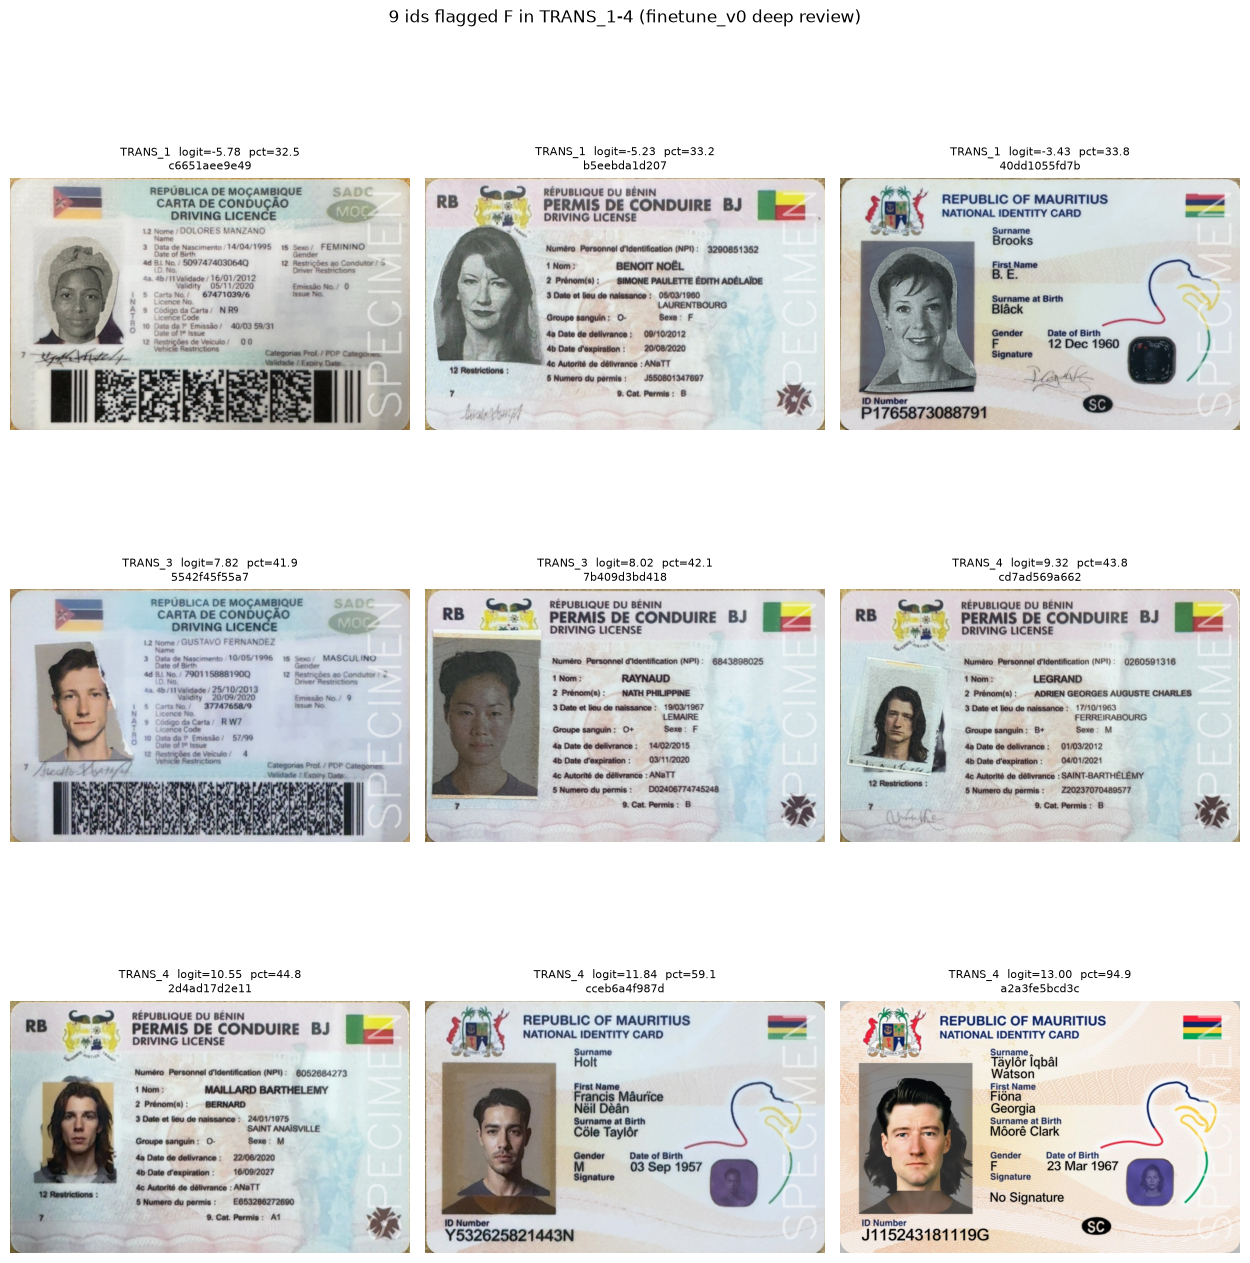

In [3]:
n = len(flagged)
cols = 3
rows = -(-n // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 4.6))
axes = axes.flatten()

for ax, row in zip(axes, flagged.itertuples(index=False)):
    try:
        img = Image.open(row.path).convert("RGB")
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, "load\nfailed", ha="center", va="center")
    ax.set_title(f"{row.stratum}  logit={row.logit:.2f}  pct={row.pct_rank:.1f}\n{row.id[:12]}", fontsize=8)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("9 ids flagged F in TRANS_1-4 (finetune_v0 deep review)", y=1.0)
fig.tight_layout()
plt.show()

## Save copies for offline viewing

Copies the 9 originals into `notebooks/trans_1_4_flagged_out/`, named `<stratum>_<id>.jpeg` so they sort by stratum. Read-only source access -- this only copies out, never touches `data/`.

In [4]:
OUT_DIR = REPO_ROOT / "notebooks" / "trans_1_4_flagged_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for row in flagged.itertuples(index=False):
    if not Path(row.path).exists():
        continue
    dest = OUT_DIR / f"{row.stratum}_{row.id}.jpeg"
    shutil.copy(row.path, dest)

saved = sorted(OUT_DIR.glob("*.jpeg"))
print(f"{len(saved)} images saved to {OUT_DIR}")
for p in saved:
    print(f"  {p.name}")

9 images saved to C:\Users\Hyun Young Jeong\Documents\Programming\kaggle_freuid_2026\notebooks\trans_1_4_flagged_out
  TRANS_1_40dd1055fd7b4fedb5a34d3ad34e8960.jpeg
  TRANS_1_b5eebda1d20743d9a364523ee2b6e506.jpeg
  TRANS_1_c6651aee9e494aaa89747630524f1ab7.jpeg
  TRANS_3_5542f45f55a74485802f33efdd58d677.jpeg
  TRANS_3_7b409d3bd41844e5b62ae6a936c9b0e8.jpeg
  TRANS_4_2d4ad17d2e1149bd8632f503d82e7455.jpeg
  TRANS_4_a2a3fe5bcd3c4a808b188e355ed052b7.jpeg
  TRANS_4_cceb6a4f987d4cdaa92979217cf99667.jpeg
  TRANS_4_cd7ad569a66244ff9adb29f7182cc270.jpeg


## Zoom into a single image

Set `idx` to a row number from the table above (0-8) to inspect one image full-size, with its full metadata printed.

id=c6651aee9e494aaa89747630524f1ab7  stratum=TRANS_1  logit=-5.7813  pct_rank=32.50
doc_type_proxy=MAURITIUS/ID  type_proxy_similarity=0.9894  face_score=0.7737
blur=272.76  moire=22.38  blockiness=0.3380  min_side_px=530
hesitant_cosine_mean=-0.7380  note=nan
size=(840, 530)


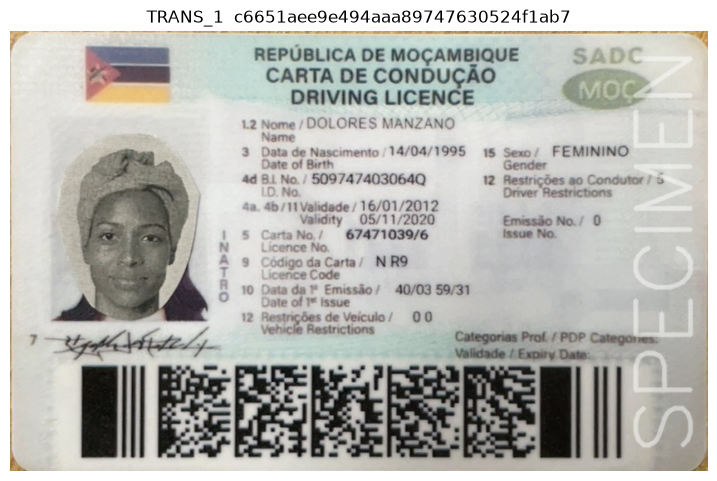

In [5]:
idx = 0  # <- change this to look at a different row (0-8)

row = flagged.iloc[idx]
img = Image.open(row["path"]).convert("RGB")
print(f"id={row['id']}  stratum={row['stratum']}  logit={row['logit']:.4f}  pct_rank={row['pct_rank']:.2f}")
print(f"doc_type_proxy={row['doc_type_proxy']}  type_proxy_similarity={row['type_proxy_similarity']:.4f}  face_score={row['face_score']:.4f}")
print(f"blur={row['blur_laplacian_var']:.2f}  moire={row['moire_fft_score']:.2f}  blockiness={row['blockiness_score']:.4f}  min_side_px={row['min_side_px']:.0f}")
print(f"hesitant_cosine_mean={row['hesitant_cosine_mean']:.4f}  note={row['note']}")
print(f"size={img.size}")
plt.figure(figsize=(9, 9))
plt.imshow(img)
plt.axis("off")
plt.title(f"{row['stratum']}  {row['id']}")
plt.show()